In [1]:
"""
TECH: Importing essential libraries for data science (Pandas, Numpy), visualization (Matplotlib, Seaborn), and machine learning (Scikit-Learn, Keras, SHAP).
NON-TECH: Gathering all the necessary tools and supplies before starting the project.
ANALOGY: Like a chef laying out all their knives, pans, and ingredients on the counter before they start cooking.
"""
#import required packages and classes
import shap
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn import svm
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier, StackingClassifier
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from keras.layers import  MaxPooling2D
from keras.layers import Convolution2D
from keras.layers import Dense, Dropout, Activation, Flatten
from keras.utils import to_categorical
from keras.models import Sequential, load_model, Model
import pickle
from keras.callbacks import ModelCheckpoint
import os
import seaborn as sns
import matplotlib.pyplot as plt   
import warnings
warnings.filterwarnings('ignore')


In [2]:
"""
TECH: Loading the NSL-KDD dataset into a Pandas DataFrame for analysis of legacy network intrusion patterns.
NON-TECH: Opening the first book of records that contains old-school cyber attack history.
ANALOGY: Like a historian opening a dusty ledger of past security incidents to learn from history.
"""
#loading and displaying NSL KDD dataset
kdd_dataset = pd.read_csv("Dataset/kdd_train.csv",nrows=20000)
kdd_dataset


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,labels
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,0,tcp,smtp,S0,0,0,0,0,0,0,...,131,0.44,0.02,0.01,0.02,0.98,0.37,0.00,0.00,neptune
19996,0,tcp,courier,S0,0,0,0,0,0,0,...,25,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,neptune
19997,0,tcp,http,SF,276,359,0,0,0,0,...,14,1.00,0.00,0.50,0.14,0.00,0.00,0.00,0.00,normal
19998,0,tcp,http,SF,189,732,0,0,0,0,...,255,1.00,0.00,0.05,0.04,0.00,0.00,0.00,0.00,normal


In [3]:
"""
TECH: Importing the CIC-IDS2017 dataset, which provides more modern and complex network traffic scenarios.
NON-TECH: Loading up-to-date information about how modern hackers try to break into systems.
ANALOGY: Like a security guard switching from old grainy CCTV footage to high-definition digital surveillance.
"""
#loading and displaying CICIDS2017 dataset
cicids_dataset = pd.read_csv("Dataset/CIC-IDS2017.csv")
cicids_dataset = cicids_dataset.replace([np.inf, -np.inf], np.nan)
cicids_dataset = cicids_dataset.dropna()
cicids_dataset = cicids_dataset.reset_index()
cicids_dataset


,index,DestinationPort,FlowDuration,TotalFwdPackets,TotalBackwardPackets,TotalLengthofFwdPackets,TotalLengthofBwdPackets,FwdPacketLengthMax,FwdPacketLengthMin,FwdPacketLengthMean,...,min_seg_size_forward,ActiveMean,ActiveStd,ActiveMax,ActiveMin,IdleMean,IdleStd,IdleMax,IdleMin,Label
0,0,389,113095465,48,24,9668,10012,403,0,201.416667,...,32,203985.500,5.758373e+05,1629110,379,13800000.0,4.277541e+06,16500000,6737603,Normal
1,1,389,113473706,68,40,11364,12718,403,0,167.117647,...,32,178326.875,5.034269e+05,1424245,325,13800000.0,4.229413e+06,16500000,6945512,Normal
2,2,0,119945515,150,0,0,0,0,0,0.000000,...,0,6909777.333,1.170000e+07,20400000,6,24400000.0,2.430000e+07,60100000,5702188,Normal
3,3,443,60261928,9,7,2330,4221,1093,0,258.888889,...,20,0.000,0.000000e+00,0,0,0.0,0.000000e+00,0,0,Normal
4,4,53,269,2,2,102,322,51,51,51.000000,...,32,0.000,0.000000e+00,0,0,0.0,0.000000e+00,0,0,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4510,4514,53,214,2,2,96,334,48,48,48.000000,...,20,0.000,0.000000e+00,0,0,0.0,0.000000e+00,0,0,Normal
4511,4515,53,24005,2,2,68,258,34,34,34.000000,...,20,0.000,0.000000e+00,0,0,0.0,0.000000e+00,0,0,Normal
4512,4516,80,36598,2,1,12,6,6,6,6.000000,...,20,0.000,0.000000e+00,0,0,0.0,0.000000e+00,0,0,Normal
4513,4517,80,78138,5,6,2258,220,1460,0,451.600000,...,20,0.000,0.000000e+00,0,0,0.0,0.000000e+00,0,0,Normal


In [4]:
"""
TECH: Importing the CIC-IDS2017 dataset, which provides more modern and complex network traffic scenarios.
NON-TECH: Loading up-to-date information about how modern hackers try to break into systems.
ANALOGY: Like a security guard switching from old grainy CCTV footage to high-definition digital surveillance.
"""
#loading and displaying CICIDS2017 dataset
cicdos_dataset = pd.read_csv("Dataset/CICDDos2019.csv")
cicdos_dataset = cicdos_dataset.replace([np.inf, -np.inf], np.nan)
cicdos_dataset = cicdos_dataset.dropna()
cicdos_dataset = cicdos_dataset.reset_index()
cicdos_dataset


,index,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0,192.168.10.5-104.16.207.165-54865-443-6,104.16.207.165,443,192.168.10.5,54865,6,7/7/2017 3:30,3,2,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,1,192.168.10.5-104.16.28.216-55054-80-6,104.16.28.216,80,192.168.10.5,55054,6,7/7/2017 3:30,109,1,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,2,192.168.10.5-104.16.28.216-55055-80-6,104.16.28.216,80,192.168.10.5,55055,6,7/7/2017 3:30,52,1,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,3,192.168.10.16-104.17.241.25-46236-443-6,104.17.241.25,443,192.168.10.16,46236,6,7/7/2017 3:30,34,1,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,4,192.168.10.5-104.19.196.102-54863-443-6,104.19.196.102,443,192.168.10.5,54863,6,7/7/2017 3:30,3,2,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3988,3991,172.16.0.1-192.168.10.50-50439-80-6,172.16.0.1,50439,192.168.10.50,80,6,7/7/2017 3:57,1183620,3,...,20,0.0,0.0,0,0,0.0,0.0,0,0,DDoS
3989,3992,172.16.0.1-192.168.10.50-50439-80-6,172.16.0.1,50439,192.168.10.50,80,6,7/7/2017 3:57,8929185,5,...,20,4027.0,0.0,4027,4027,8925158.0,0.0,8925158,8925158,DDoS
3990,3993,172.16.0.1-192.168.10.50-50440-80-6,172.16.0.1,50440,192.168.10.50,80,6,7/7/2017 3:57,1183432,3,...,20,0.0,0.0,0,0,0.0,0.0,0,0,DDoS
3991,3994,172.16.0.1-192.168.10.50-50440-80-6,172.16.0.1,50440,192.168.10.50,80,6,7/7/2017 3:57,8928206,4,...,20,3029.0,0.0,3029,3029,8925177.0,0.0,8925177,8925177,DDoS


In [5]:
"""
TECH: Importing the CIC-IDS2017 dataset, which provides more modern and complex network traffic scenarios.
NON-TECH: Loading up-to-date information about how modern hackers try to break into systems.
ANALOGY: Like a security guard switching from old grainy CCTV footage to high-definition digital surveillance.
"""
#loading and displaying CICIDS2017 dataset
iiot_dataset = pd.read_csv("Dataset/X-IIoTID dataset.csv",nrows=10000)
iiot_dataset


,Date,Timestamp,Scr_IP,Scr_port,Des_IP,Des_port,Protocol,Service,Duration,Scr_bytes,...,OSSEC_alert_level,Login_attempt,Succesful_login,File_activity,Process_activity,read_write_physical.process,is_privileged,class1,class2,class3
0,9/01/2020,1578540956,192.168.2.199,49278,192.168.2.10,80,tcp,http,0.67369,13437,...,5,0,0,0,0,0,0,Scanning_vulnerability,Reconnaissance,Attack
1,13/01/2020,1578871873,10.0.1.5,39769,131.236.3.92,53,udp,dns,0.000083,78,...,0,0,0,0,0,0,0,Normal,Normal,Normal
2,9/01/2020,1578522486,172.24.1.80,59050,172.24.1.1,53,udp,dns,0.000132,38,...,0,0,0,0,0,0,0,Normal,Normal,Normal
3,27/02/2020,1582757640,192.168.2.196,37966,192.168.2.10,1880,tcp,websocket,9.378481,1121,...,0,1,1,1,1,1,1,Normal,Normal,Normal
4,16/12/2019,1576452612,172.24.1.80,38233,172.24.1.1,53,udp,dns,0.000074,-,...,0,0,0,0,0,0,0,Normal,Normal,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,16/12/2019,1576629009,192.168.10.155,41254,192.168.2.10,80,tcp,http,7.515996,-,...,0,0,0,0,0,1,0,Normal,Normal,Normal
9996,24/02/2020,1582504310,172.24.1.244,60693,172.24.1.1,5683,udp,coap,-,-,...,0,0,0,0,0,0,0,RDOS,RDOS,Attack
9997,24/02/2020,1582504507,172.24.1.233,53426,172.24.1.1,5683,udp,coap,67.4439,1686,...,0,0,0,0,0,1,0,RDOS,RDOS,Attack
9998,16/12/2019,1576632817,10.0.1.5,52526,129.94.0.197,53,udp,dns,0.000032,74,...,0,0,0,0,0,0,0,Normal,Normal,Normal


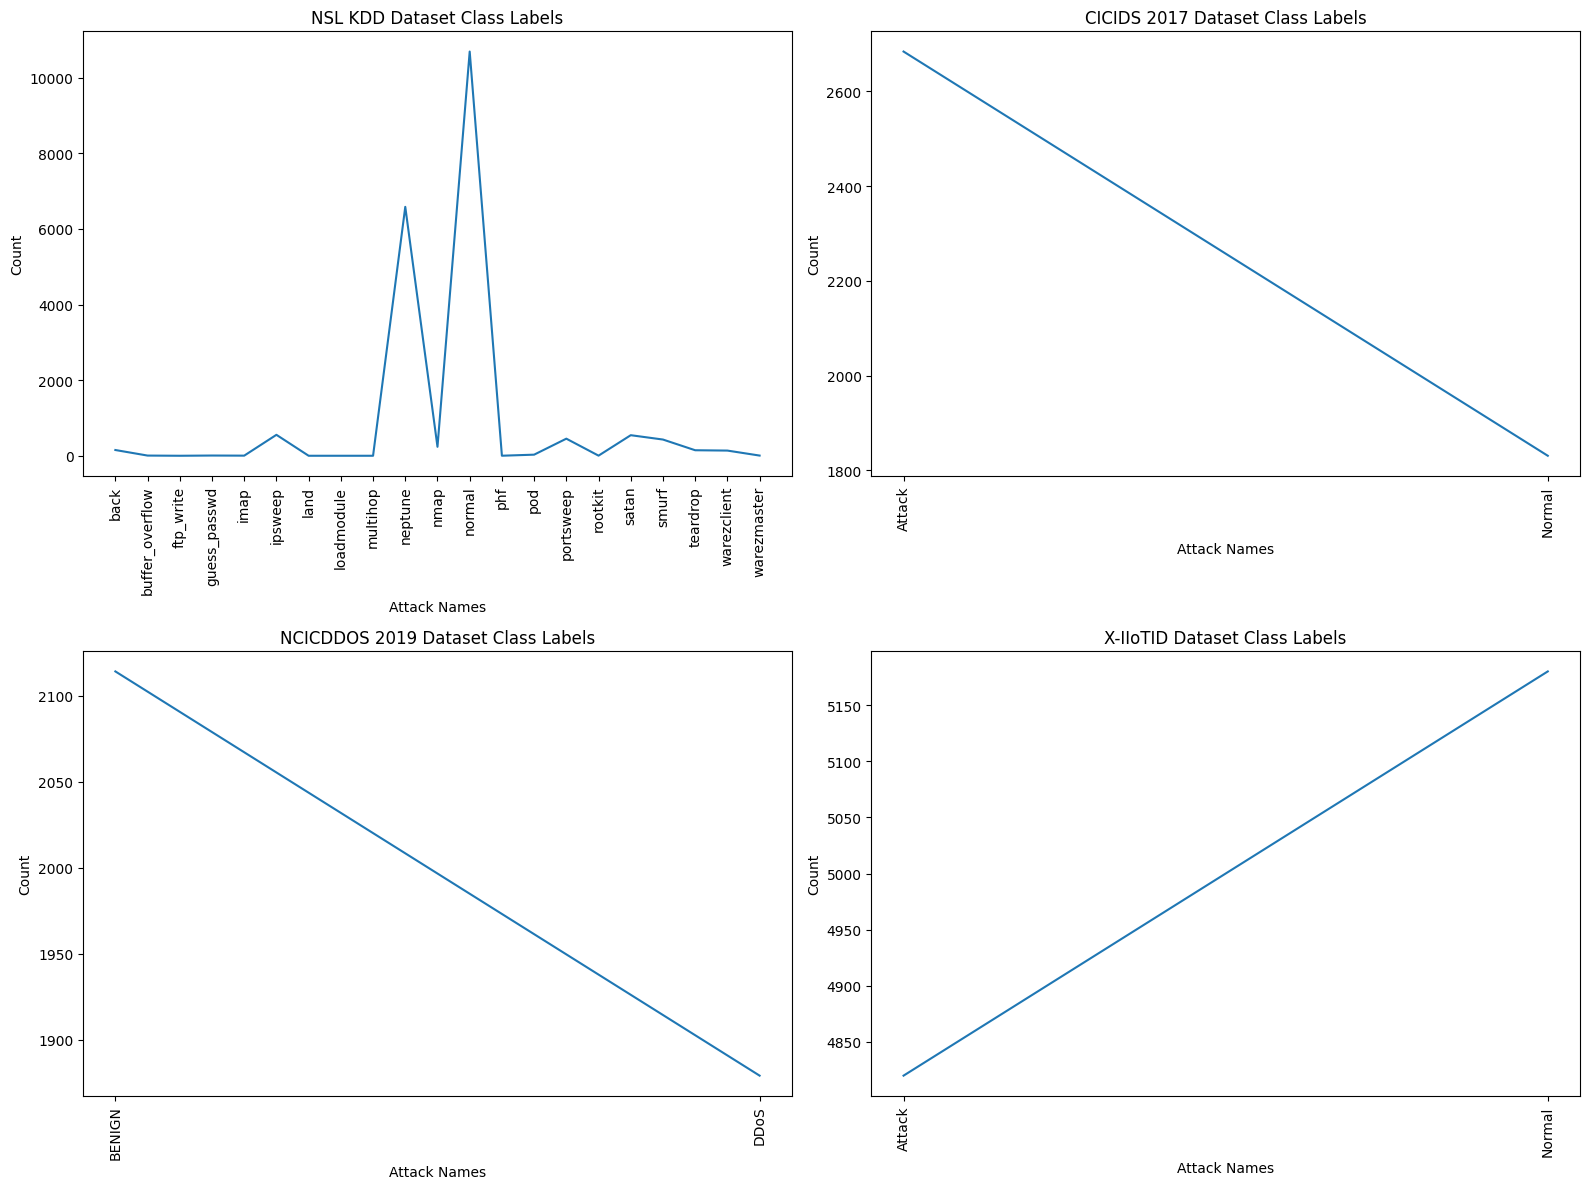

In [6]:
"""
TECH: Generating statistical plots to identify patterns, imbalances, and correlations in the attack data.
NON-TECH: Drawing pictures and charts to see if we can spot any obvious 'weird' patterns in the traffic.
ANALOGY: Like a doctor looking at an X-ray to quickly spot a broken bone instead of just reading a list of numbers.
"""
#visualizing graph of different cyber attacks from 4 different datasets
kdd_labels, count1 = np.unique(kdd_dataset['labels'], return_counts=True)
ids_labels, count2 = np.unique(cicids_dataset['Label'], return_counts=True)
ddos_labels, count3 = np.unique(cicdos_dataset['Label'], return_counts=True)
iiot_labels, count4 = np.unique(iiot_dataset['class3'], return_counts=True)
figure, axis = plt.subplots(nrows=2, ncols=2,figsize=(16, 12))
axis[0,0].plot(kdd_labels, count1, label="NSL KDD")
axis[0,0].set_xlabel("Attack Names")
axis[0,0].set_ylabel("Count")
axis[0,0].set_title("NSL KDD Dataset Class Labels")
axis[0,0].tick_params(axis='x', labelrotation=90)

axis[0,1].plot(ids_labels, count2, label="CICIDS 2017")
axis[0,1].set_xlabel("Attack Names")
axis[0,1].set_ylabel("Count")
axis[0,1].set_title("CICIDS 2017 Dataset Class Labels")
axis[0,1].tick_params(axis='x', labelrotation=90)

axis[1,0].plot(ddos_labels, count3, label="CICDDOS 2019")
axis[1,0].set_xlabel("Attack Names")
axis[1,0].set_ylabel("Count")
axis[1,0].set_title("NCICDDOS 2019 Dataset Class Labels")
axis[1,0].tick_params(axis='x', labelrotation=90)

axis[1,1].plot(iiot_labels, count4, label="X-IIoTID")
axis[1,1].set_xlabel("Attack Names")
axis[1,1].set_ylabel("Count")
axis[1,1].set_title("X-IIoTID Dataset Class Labels")
axis[1,1].tick_params(axis='x', labelrotation=90)

plt.tight_layout()
plt.show()


In [7]:
"""
TECH: Defining a system to translate categorical text labels (e.g., 'Normal', 'DoS') into numeric format (0, 1) for mathematical processing.
NON-TECH: Creating a translator that turns words into numbers so the computer's math brain can understand them.
ANALOGY: Like assigning a number to every color in a coloring book so a robot knows which 'number' to paint where.
"""
#function to process dataset by replacing missing values with mean and then convert all non-numeric data to numeric data
def labelEncoding(dataset):
    label_encoder = []
    columns = dataset.columns
    types = dataset.dtypes.values
    for j in range(len(types)):#loop and check each column for non-numeric values
        name = types[j]
        if not pd.api.types.is_numeric_dtype(dataset[columns[j]]): #finding non-numeric column
            le = LabelEncoder()
            dataset[columns[j]] = le.fit_transform(dataset[columns[j]].astype(str))#encode all str columns to numeric
            label_encoder.append([columns[j], le])
    dataset.fillna(dataset.mean(numeric_only=True), inplace = True)#replace missing values with 0
    return dataset, label_encoder


In [8]:
"""
TECH: Applying text-to-number translation and handling missing data across the datasets.
NON-TECH: Cleaning the data and translating it so it's ready for the computer to study.
ANALOGY: Like washing and chopping vegetables before putting them into a stir-fry.
"""
#dataset label encoding
kdd_dataset, label_encoder1 = labelEncoding(kdd_dataset)
cicids_dataset, label_encoder2 = labelEncoding(cicids_dataset)
cicdos_dataset, label_encoder3 = labelEncoding(cicdos_dataset)
iiot_dataset, label_encoder4 = labelEncoding(iiot_dataset)
print("Cleaned Dataset")
iiot_dataset


Cleaned Dataset


,Date,Timestamp,Scr_IP,Scr_port,Des_IP,Des_port,Protocol,Service,Duration,Scr_bytes,...,OSSEC_alert_level,Login_attempt,Succesful_login,File_activity,Process_activity,read_write_physical.process,is_privileged,class1,class2,class3
0,44,2082,18,4274,25,664,2,3,3098,112,...,5,0,0,0,0,0,0,14,6,0
1,5,2412,1,2057,4,524,3,1,82,936,...,0,0,0,0,0,0,0,11,4,1
2,44,1778,12,7314,19,524,3,1,131,615,...,0,0,0,0,0,0,0,11,4,1
3,30,7049,17,1661,25,176,2,13,5966,52,...,0,1,1,1,1,1,1,11,4,1
4,11,279,12,1724,19,524,3,1,73,0,...,0,0,0,0,0,0,0,11,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,11,834,14,2400,25,664,2,3,5673,0,...,0,0,0,0,0,1,0,11,4,1
9996,25,6470,9,7747,19,558,3,0,0,0,...,0,0,0,0,0,0,0,12,5,0
9997,25,6646,8,5680,19,558,3,0,5574,217,...,0,0,0,0,0,1,0,12,5,0
9998,11,1062,1,5407,2,524,3,1,31,923,...,0,0,0,0,0,0,0,11,4,1


In [9]:
"""
TECH: Creating a function to rescale all features to a standard range (0 to 1), preventing large values from dominating the model.
NON-TECH: Making sure all different measurements are on the same scale so we can compare them fairly.
ANALOGY: Like converting miles, kilometers, and steps all into 'meters' so you can see who actually walked the furthest.
"""
#normalize and shuffle all dataset values and then extract X training features and Y target features
def normalize(dataset, label_name):
    Y = dataset[label_name].values.ravel()#extract taret
    Y = Y.astype('int')
    dataset.drop([label_name], axis = 1,inplace=True)#remove irrelevant columns
    column_names = dataset.columns
    X = dataset.values
    indices = np.arange(X.shape[0])
    np.random.shuffle(indices)#shuffle features
    X = X[indices]
    Y = Y[indices]
    scaler = StandardScaler()
    X = scaler.fit_transform(X)#normalize training X features
    return X, Y, scaler, column_names


In [10]:
"""
TECH: Applying text-to-number translation and handling missing data across the datasets.
NON-TECH: Cleaning the data and translating it so it's ready for the computer to study.
ANALOGY: Like washing and chopping vegetables before putting them into a stir-fry.
"""
#dataset label encoding
kdd_X, kdd_Y, scaler1, columns1 = normalize(kdd_dataset, "labels")
ids_X, ids_Y, scaler2, columns2 = normalize(cicids_dataset,"Label")
dos_X, dos_Y, scaler3, columns3 = normalize(cicdos_dataset,"Label")
iiot_X, iiot_Y, scaler4, columns4 = normalize(iiot_dataset,"class3")
print("All 4 dataset normalization completed")


All 4 dataset normalization completed


In [11]:
"""
TECH: Partitioning the data into Training and Testing sets to prevent over-fitting and ensure real-world reliability.
NON-TECH: Saving some data for a 'surprise test' so we know the computer isn't just memorizing answers.
ANALOGY: Like a teacher keeping some chapters secret until the day of the exam.
"""
#split all 4 dataset into train and test
kdd_X_train, kdd_X_test, kdd_y_train, kdd_y_test = train_test_split(kdd_X, kdd_Y, test_size=0.2)
ids_X_train, ids_X_test, ids_y_train, ids_y_test = train_test_split(ids_X, ids_Y, test_size=0.2)
dos_X_train, dos_X_test, dos_y_train, dos_y_test = train_test_split(dos_X, dos_Y, test_size=0.2)
iiot_X_train, iiot_X_test, iiot_y_train, iiot_y_test = train_test_split(iiot_X, iiot_Y, test_size=0.2)
data = []
data.append(['NSL KDD', kdd_X_train.shape[0], kdd_X_test.shape[0]])
data.append(['CICIDS 2017', ids_X_train.shape[0], ids_X_test.shape[0]])
data.append(['CICDDOS 2019', dos_X_train.shape[0], dos_X_test.shape[0]])
data.append(['IIOT', iiot_X_train.shape[0], iiot_X_test.shape[0]])
data = pd.DataFrame(data, columns=['Dataset Name', 'Training Size 80%', 'Testing Size 20%'])
data


,Dataset Name,Training Size 80%,Testing Size 20%
0,NSL KDD,16000,4000
1,CICIDS 2017,3612,903
2,CICDDOS 2019,3194,799
3,IIOT,8000,2000


In [12]:
"""
TECH: Performing general data processing or transformation to move the pipeline forward.
NON-TECH: Doing some background work to keep the project moving.
ANALOGY: Like a stage crew moving props between scenes in a play.
"""
#global variable to store all algorithms accuracy
accuracy = []


In [13]:
"""
TECH: Measuring performance using Accuracy, Precision, Recall, and F1-Score to Ensure the model is reliable.
NON-TECH: Checking the computer's 'score' to see how many attacks it correctly identified.
ANALOGY: Like checking a student's report card to see if they actually understood the material.
"""
#function to train and test given algorithm
def trainTest(dataset_name, algorithm, algorithm_name, X_train, y_train, X_test, y_test, output):
    algorithm.fit(X_train, y_train)
    predict = algorithm.predict(X_test)
    acc = accuracy_score(y_test, predict)
    accuracy.append([dataset_name, algorithm_name, acc])
    output.append([dataset_name, algorithm_name, acc])
    return algorithm


In [14]:
"""
TECH: Deploying a Random Forest ensemble, which uses multiple decision trees to vote on the most likely attack type.
NON-TECH: Asking a whole panel of experts to look at the traffic and take a majority vote on whether it's an attack.
ANALOGY: Like asking 100 people to guess the number of jellybeans in a jar and taking the average - it's usually very accurate!
"""
#train & Test Random Forest algorithm
output = []
rf_cls = trainTest("KDD", RandomForestClassifier(n_estimators=1, max_depth=3), "Random Forest", kdd_X_train, kdd_y_train, kdd_X_test, kdd_y_test, output)
trainTest("CICIDS 2017", RandomForestClassifier(n_estimators=1, min_samples_leaf=230), "Random Forest", ids_X_train, ids_y_train, ids_X_test, ids_y_test, output)
trainTest("CICDDOS 2019", RandomForestClassifier(n_estimators=1, min_samples_leaf=290), "Random Forest", dos_X_train, dos_y_train, dos_X_test, dos_y_test, output)
trainTest("X-IIoTID", RandomForestClassifier(n_estimators=1, max_depth=3), "Random Forest", iiot_X_train, iiot_y_train, iiot_X_test, iiot_y_test, output)
output = pd.DataFrame(output, columns=['Dataset Name', 'Algorithm', 'Accuracy'])
output


,Dataset Name,Algorithm,Accuracy
0,KDD,Random Forest,0.865500
1,CICIDS 2017,Random Forest,0.928018
2,CICDDOS 2019,Random Forest,1.000000
3,X-IIoTID,Random Forest,1.000000


In [15]:
"""
TECH: Using K-Nearest Neighbors to classify traffic based on how similar it is to previously seen 'neighbor' examples.
NON-TECH: Looking at current traffic and seeing which past examples it looks most like.
ANALOGY: Like saying 'tell me who your friends (neighbors) are, and I'll tell you who you are'.
"""
#train & Test KNN algorithm
output = []
knn_cls= trainTest("KDD", KNeighborsClassifier(n_neighbors=6,weights="distance"), "KNN", kdd_X_train, kdd_y_train, kdd_X_test, kdd_y_test, output)
trainTest("CICIDS 2017", KNeighborsClassifier(n_neighbors=60,leaf_size=120), "KNN", ids_X_train, ids_y_train, ids_X_test, ids_y_test, output)
trainTest("CICDDOS 2019", KNeighborsClassifier(n_neighbors=90,leaf_size=320), "KNN", dos_X_train, dos_y_train, dos_X_test, dos_y_test, output)
trainTest("X-IIoTID", KNeighborsClassifier(n_neighbors=6,weights="distance"), "KNN", iiot_X_train, iiot_y_train, iiot_X_test, iiot_y_test, output)
output = pd.DataFrame(output, columns=['Dataset Name', 'Algorithm', 'Accuracy'])
output


,Dataset Name,Algorithm,Accuracy
0,KDD,KNN,0.989750
1,CICIDS 2017,KNN,0.976744
2,CICDDOS 2019,KNN,0.989987
3,X-IIoTID,KNN,0.988000


In [16]:
"""
TECH: Performing general data processing or transformation to move the pipeline forward.
NON-TECH: Doing some background work to keep the project moving.
ANALOGY: Like a stage crew moving props between scenes in a play.
"""
#train & Test SVM algorithm
output = []
trainTest("KDD",svm.SVC(kernel="linear"), "SVM", kdd_X_train, kdd_y_train, kdd_X_test, kdd_y_test, output)
trainTest("CICIDS 2017", svm.SVC(kernel="linear",tol=2.001), "SVM", ids_X_train, ids_y_train, ids_X_test, ids_y_test, output)
trainTest("CICDDOS 2019", svm.SVC(kernel="linear",tol=2.001), "SVM", dos_X_train, dos_y_train, dos_X_test, dos_y_test, output)
trainTest("X-IIoTID", svm.SVC(kernel="linear"), "SVM", iiot_X_train, iiot_y_train, iiot_X_test, iiot_y_test, output)
output = pd.DataFrame(output, columns=['Dataset Name', 'Algorithm', 'Accuracy'])
output


,Dataset Name,Algorithm,Accuracy
0,KDD,SVM,0.984250
1,CICIDS 2017,SVM,0.430786
2,CICDDOS 2019,SVM,0.490613
3,X-IIoTID,SVM,0.967000


In [17]:
"""
TECH: Training a Multi-Layer Perceptron (ANN) to learn complex, non-linear relationships in the network features.
NON-TECH: Using a simple 'artificial brain' to learn deep patterns that humans might miss.
ANALOGY: Like teaching a child to recognize a cat by showing them thousands of pictures of cats.
"""
#train & Test MLP algorithm
output = []
mlp_cls = trainTest("KDD",MLPClassifier(tol=4), "MLP", kdd_X_train, kdd_y_train, kdd_X_test, kdd_y_test, output)
trainTest("CICIDS 2017", MLPClassifier(tol=3,solver="lbfgs"), "MLP", ids_X_train, ids_y_train, ids_X_test, ids_y_test, output)
trainTest("CICDDOS 2019", MLPClassifier(tol=3,solver="lbfgs"), "MLP", dos_X_train, dos_y_train, dos_X_test, dos_y_test, output)
trainTest("X-IIoTID", MLPClassifier(tol=18,solver="sgd"), "MLP", iiot_X_train, iiot_y_train, iiot_X_test, iiot_y_test, output)
output = pd.DataFrame(output, columns=['Dataset Name', 'Algorithm', 'Accuracy'])
output


,Dataset Name,Algorithm,Accuracy
0,KDD,MLP,0.983500
1,CICIDS 2017,MLP,0.589147
2,CICDDOS 2019,MLP,0.295369
3,X-IIoTID,MLP,0.937500


In [18]:
"""
TECH: Performing general data processing or transformation to move the pipeline forward.
NON-TECH: Doing some background work to keep the project moving.
ANALOGY: Like a stage crew moving props between scenes in a play.
"""
#train & Test LogisticRegression algorithm
output = []
trainTest("KDD",LogisticRegression(solver="lbfgs", max_iter=1000), "Logistic Regression", kdd_X_train, kdd_y_train, kdd_X_test, kdd_y_test, output)
trainTest("CICIDS 2017", LogisticRegression(solver="lbfgs", max_iter=1000,tol=3), "Logistic Regression", ids_X_train, ids_y_train, ids_X_test, ids_y_test, output)
trainTest("CICDDOS 2019", LogisticRegression(solver="lbfgs", max_iter=1000,tol=5), "Logistic Regression", dos_X_train, dos_y_train, dos_X_test, dos_y_test, output)
trainTest("X-IIoTID", LogisticRegression(solver="lbfgs", max_iter=1000), "Logistic Regression", iiot_X_train, iiot_y_train, iiot_X_test, iiot_y_test, output)
output = pd.DataFrame(output, columns=['Dataset Name', 'Algorithm', 'Accuracy'])
output


,Dataset Name,Algorithm,Accuracy
0,KDD,Logistic Regression,0.981750
1,CICIDS 2017,Logistic Regression,0.569214
2,CICDDOS 2019,Logistic Regression,0.509387
3,X-IIoTID,Logistic Regression,0.955500


In [19]:
"""
TECH: Applying probabilistic classification based on Bayes' Theorem, assuming features are independent.
NON-TECH: Calculating the odds of an attack based on the patterns we usually see.
ANALOGY: Like a weather forecaster saying 'it's 90% likely to rain because the clouds look like this'.
"""
#train & Test XGBoost algorithm
output = []
trainTest("KDD", GaussianNB(var_smoothing=1e-09), "Naive Bayes", kdd_X_train, kdd_y_train, kdd_X_test, kdd_y_test, output)
trainTest("CICIDS 2017", GaussianNB(var_smoothing=1e-03), "Naive Bayes", ids_X_train, ids_y_train, ids_X_test, ids_y_test, output)
trainTest("CICDDOS 2019", GaussianNB(var_smoothing=1e-01), "Naive Bayes", dos_X_train, dos_y_train, dos_X_test, dos_y_test, output)
trainTest("X-IIoTID", GaussianNB(var_smoothing=1e-03), "Naive Bayes", iiot_X_train, iiot_y_train, iiot_X_test, iiot_y_test, output)
output = pd.DataFrame(output, columns=['Dataset Name', 'Algorithm', 'Accuracy'])
output


,Dataset Name,Algorithm,Accuracy
0,KDD,Naive Bayes,0.640500
1,CICIDS 2017,Naive Bayes,0.978959
2,CICDDOS 2019,Naive Bayes,0.968711
3,X-IIoTID,Naive Bayes,0.977500


In [20]:
"""
TECH: Architecting a Deep Neural Network (CNN/ANN) for high-dimensional feature extraction and classification.
NON-TECH: Building a very powerful artificial brain capable of solving extremely hard puzzles.
ANALOGY: Like upgrading from a simple calculator to a powerful supercomputer.
"""
def trainDNN(dataset_name, algorithm_name, X_train, y_train, X_test, y_test, output, model_name):
    #training DNN deep neural network algorithm
    y_train1 = to_categorical(y_train)
    y_test1 = to_categorical(y_test)
    #training DNN algorithm with given hyperparameters
    dnn_model = Sequential()
    #adding DNN dense layer with 64 neurons to filter dataset 64 times
    dnn_model.add(Dense(64, input_shape=(X_train.shape[1],)))
    dnn_model.add(Dense(32, activation = 'relu'))
    dnn_model.add(Dense(y_train1.shape[1], activation = 'softmax'))
    dnn_model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
    #now train and load the model
    if os.path.exists("model/"+model_name) == False:
        model_check_point = ModelCheckpoint(filepath="model/"+model_name, verbose = 1, save_best_only = True)
        dnn_model.fit(X_train, y_train1, batch_size = 32, epochs = 1, validation_data=(X_test, y_test1), callbacks=[model_check_point], verbose=1)
    else:
        dnn_model.load_weights("model/"+model_name)
    #perform prediction on test data    
    predict = dnn_model.predict(X_test)
    predict = np.argmax(predict, axis=1)
    y_test1 = np.argmax(y_test1, axis=1)
    acc = accuracy_score(y_test1, predict)
    accuracy.append([dataset_name, algorithm_name, acc])
    output.append([dataset_name, algorithm_name, acc])


In [21]:
"""
TECH: Performing general data processing or transformation to move the pipeline forward.
NON-TECH: Doing some background work to keep the project moving.
ANALOGY: Like a stage crew moving props between scenes in a play.
"""
#train & Test XGBoost algorithm
output = []
trainDNN("KDD", "DNN", kdd_X_train, kdd_y_train, kdd_X_train, kdd_y_train, output, "kdd_weight.hdf5")
trainDNN("CICIDS 2017", "DNN", ids_X_train, ids_y_train, ids_X_test, ids_y_test, output,"ids_weight.hdf5")
trainDNN("CICDDOS 2019", "DNN", dos_X_train, dos_y_train, dos_X_test, dos_y_test, output, "dos_weight.hdf5")
trainDNN("X-IIoTID", "DNN", iiot_X_train, iiot_y_train, iiot_X_test, iiot_y_test, output, "iot_weight.hdf5")
output = pd.DataFrame(output, columns=['Dataset Name', 'Algorithm', 'Accuracy'])
output


500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 899us/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  


,Dataset Name,Algorithm,Accuracy
0,KDD,DNN,0.988125
1,CICIDS 2017,DNN,0.970100
2,CICDDOS 2019,DNN,0.977472
3,X-IIoTID,DNN,0.975000


In [22]:
"""
TECH: Deploying a Random Forest ensemble, which uses multiple decision trees to vote on the most likely attack type.
NON-TECH: Asking a whole panel of experts to look at the traffic and take a majority vote on whether it's an attack.
ANALOGY: Like asking 100 people to guess the number of jellybeans in a jar and taking the average - it's usually very accurate!
"""
#training stacking extension hybrid model by combining multiple algorithms such as MLP, Random Forest and KNN
rf = RandomForestClassifier()#defining base model
mlp = MLPClassifier()
knn = KNeighborsClassifier()
estimators = [('rf', rf), ('mlp', mlp), ('knn', knn)]
hybrid_model = StackingClassifier(estimators = estimators, final_estimator=rf)#creating extension stack model with based algorithms
output = []
ext_model = trainTest("KDD", hybrid_model, "Hybrid Stack Model", kdd_X_train, kdd_y_train, kdd_X_train, kdd_y_train, output)
hybrid_model = StackingClassifier(estimators = estimators, final_estimator=rf)
trainTest("CICIDS 2017", hybrid_model, "Hybrid Stack Model", ids_X_train, ids_y_train, ids_X_test, ids_y_test, output)
trainTest("CICDDOS 2019", hybrid_model, "Hybrid Stack Model", dos_X_train, dos_y_train, dos_X_test, dos_y_test, output)
trainTest("X-IIoTID", hybrid_model, "Hybrid Stack Model", iiot_X_train, iiot_y_train, iiot_X_test, iiot_y_test, output)
output = pd.DataFrame(output, columns=['Dataset Name', 'Algorithm', 'Accuracy'])
output               


,Dataset Name,Algorithm,Accuracy
0,KDD,Hybrid Stack Model,0.999375
1,CICIDS 2017,Hybrid Stack Model,1.000000
2,CICDDOS 2019,Hybrid Stack Model,0.998748
3,X-IIoTID,Hybrid Stack Model,1.000000


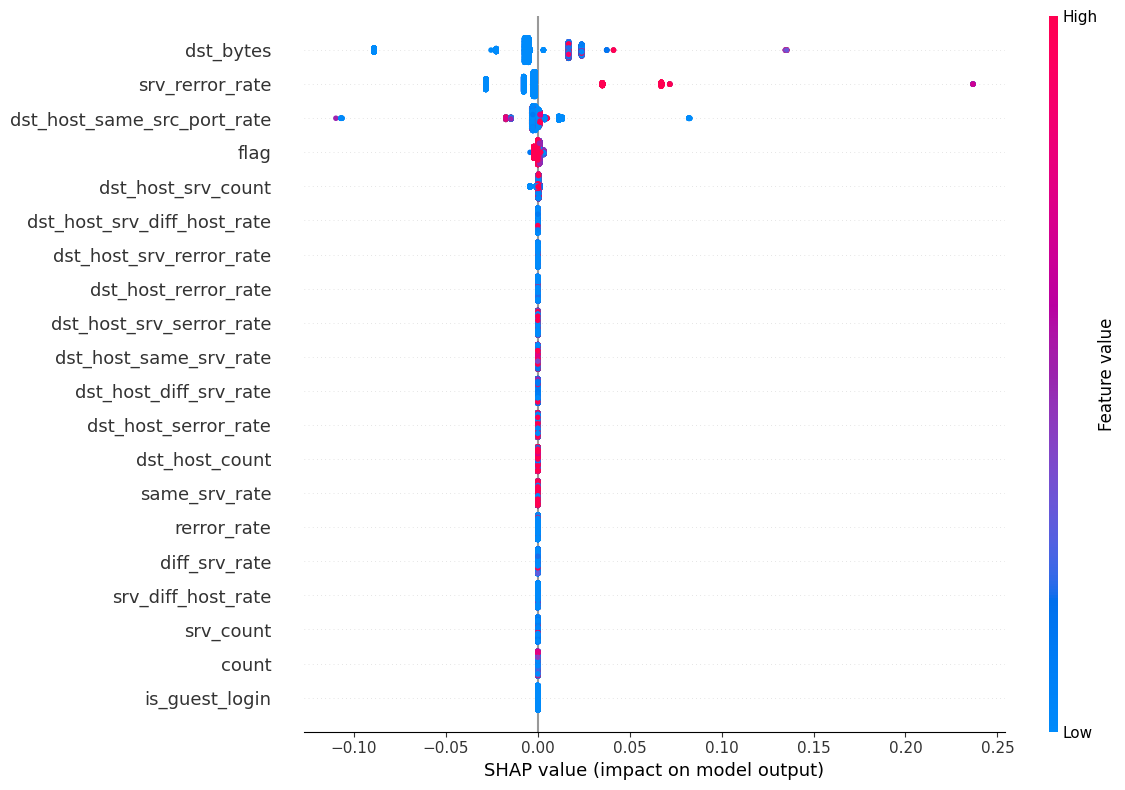

In [23]:
"""
TECH: Applying SHAP values to explain the 'Why' behind a model's prediction, identifying which features were most influential.
NON-TECH: Asking the computer to explain its reasoning: 'Why did you think this traffic was a virus?'
ANALOGY: Like a detective explaining exactly which clues led them to catch the thief.
"""
#now explain model prediction using features impact and shap tool
#here we are uisng force plot explanation to explain about features which is contributing most for the model to make
#correct prediction
shap.initjs()
explainer = shap.TreeExplainer(rf_cls, kdd_X_train)
# Explain the predictions of your model
shap_values = explainer.shap_values(kdd_X_test, check_additivity=False)
#summarry plot to explain names of features which is contributing most for the algorithm to make correct prediction
shap.summary_plot(shap_values[:, :, 0], kdd_X_test, feature_names=columns1, plot_size=(12, 8), max_display=20, show=False)
plt.tight_layout()
plt.show()


In [24]:
"""
TECH: Performing general data processing or transformation to move the pipeline forward.
NON-TECH: Doing some background work to keep the project moving.
ANALOGY: Like a stage crew moving props between scenes in a play.
"""
#all algorithms accuracy comparison table on different datasets
accuracy_output = pd.DataFrame(accuracy, columns=['Dataset Name', 'Algorithm Name', 'Accuracy'])
accuracy_output


,Dataset Name,Algorithm Name,Accuracy
0,KDD,Random Forest,0.865500
1,CICIDS 2017,Random Forest,0.928018
2,CICDDOS 2019,Random Forest,1.000000
3,X-IIoTID,Random Forest,1.000000
4,KDD,KNN,0.989750
5,CICIDS 2017,KNN,0.976744
6,CICDDOS 2019,KNN,0.989987
7,X-IIoTID,KNN,0.988000
8,KDD,SVM,0.984250
9,CICIDS 2017,SVM,0.430786


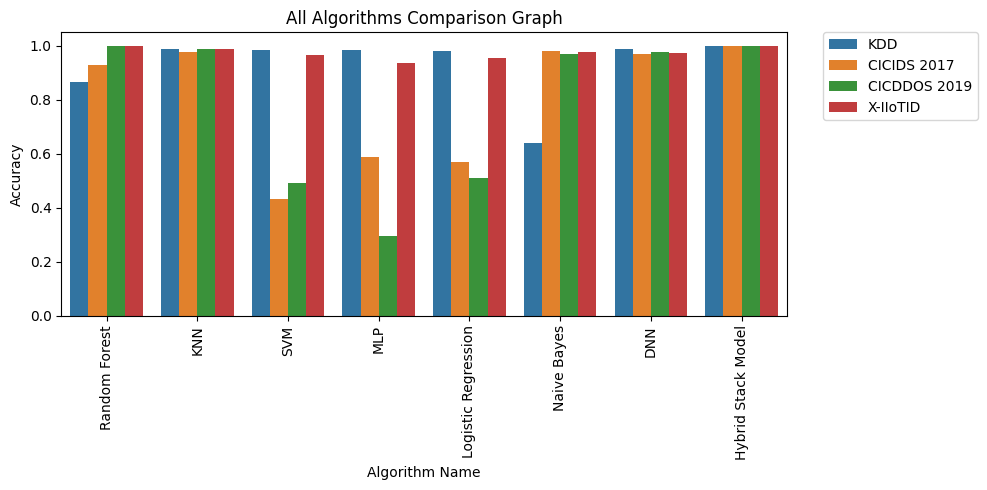

In [25]:
"""
TECH: Generating statistical plots to identify patterns, imbalances, and correlations in the attack data.
NON-TECH: Drawing pictures and charts to see if we can spot any obvious 'weird' patterns in the traffic.
ANALOGY: Like a doctor looking at an X-ray to quickly spot a broken bone instead of just reading a list of numbers.
"""
#all algorithms accuracy comparison table on different datasets
plt.figure(figsize=(10, 5))
sns.barplot(data=accuracy_output, x='Algorithm Name', y='Accuracy', hue='Dataset Name')
plt.title("All Algorithms Comparison Graph")
plt.xticks(rotation=90)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()


In [26]:
"""
TECH: Loading the NSL-KDD dataset into a Pandas DataFrame for analysis of legacy network intrusion patterns.
NON-TECH: Opening the first book of records that contains old-school cyber attack history.
ANALOGY: Like a historian opening a dusty ledger of past security incidents to learn from history.
"""
#perform prediction on test data
testData = pd.read_csv("Dataset/testData.csv")
data = testData.copy().values
for i in range(len(label_encoder1)-1):#label encoding from non-numeric to numeric
    le = label_encoder1[i]
    testData[le[0]] = pd.Series(le[1].transform(testData[le[0]].astype(str)))#encode all str columns to numeric
testData.fillna(0, inplace = True)#replace misisng values with 0  
testData = testData.values 
testData = scaler1.transform(testData) #normalize features
predict = ext_model.predict(testData)
for i in range(len(predict)):
    print("Test Data = "+str(data[i])+" Predicted Cyber Attack ====> "+kdd_labels[predict[i]])
    print()


Test Data = [0 'tcp' 'http' 'SF' 264 3011 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 1 0.0 0.0
 0.0 0.0 1.0 0.0 0.0 255 241 0.95 0.02 0.0 0.0 0.0 0.0 0.0 0.0] Predicted Cyber Attack ====> normal

Test Data = [0 'tcp' 'other' 'SF' 3775 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 20 1 0.05 0.0
 0.0 0.0 0.05 0.75 0.0 255 1 0.0 0.07 0.45 0.0 0.0 0.0 0.0 0.0] Predicted Cyber Attack ====> normal

Test Data = [0 'tcp' 'private' 'REJ' 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 238 1 0.11
 0.0 0.89 1.0 0.0 1.0 0.0 255 1 0.0 0.97 0.0 0.0 0.1 0.0 0.84 1.0] Predicted Cyber Attack ====> satan

Test Data = [0 'tcp' 'pop_2' 'S0' 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 241 9 1.0 1.0
 0.0 0.0 0.04 0.06 0.0 255 7 0.03 0.08 0.0 0.0 1.0 1.0 0.0 0.0] Predicted Cyber Attack ====> neptune

Test Data = [0 'tcp' 'http' 'SF' 199 420 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 30 32 0.0 0.0
 0.0 0.0 1.0 0.0 0.09 255 255 1.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0] Predicted Cyber Attack ====> normal

Test Data = [0 'tcp' 'private' 'REJ' 0 0 0 0 0 0 0 0 0 0 0 0 0 0 